# Prediction Interval Coverage Analysis for Smoothed Random Forests

This notebook analyzes the 95% prediction interval coverage for:
- Standard Random Forests (RF10, RF20, RF50, RF100)
- Gaussian Process (GP)
- Smoothed Random Forests (various strategies)

Well-calibrated models should achieve coverage $\approx$ 0.95

# Setup and Configuration




In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
import sys
from sklearn.metrics import mean_squared_error
import json
from scipy.stats import norm
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

In [38]:
DATASET_MAX_N_OBS = {
    'autompg': 400,
    'breastcancer': 200,
    'fertility': 100,  # Small dataset
    'forest': 500,
    'housing': 500,
    'pendulum': 500,
    'qsar_aquatic_toxicity': 500,
    'servo': 100,      # Small dataset
    'stock': 500,
    'yacht_hydrodynamics': 300 , # Medium dataset
    'real_estate': 414,
    'winequality-red': 1599,
    'winequality-white': 4898,
    'airfoil_self_noise': 1503,
    'qsar_fish_toxicity': 908,
    'Combined_Cycle_Power_Plant': 9568,
}

def get_valid_n_obs_list(data_name, requested_n_obs_list):
    """
    Filter n_obs_list based on dataset's maximum available samples
    
    Args:
        data_name: Name of the dataset
        requested_n_obs_list: List of requested sample sizes
        
    Returns:
        Filtered list of valid sample sizes
    """
    max_n_obs = DATASET_MAX_N_OBS.get(data_name, 500)
    valid_list = [n for n in requested_n_obs_list if n <= max_n_obs]
    
    return valid_list

    

In [39]:
ci_all_combined = pd.read_csv('./metrics/ci_coverage_combined_all_data.csv')

In [40]:
ci_all_combined.columns

Index(['Data', 'p', 'n_obs', 'r', 'RF(10)', 'RF(20)', 'RF(50)', 'RF(100)',
       'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)', 'STE(Norm)', 'STE(Hypsec)',
       'STE-PD(Norm)', 'STE-PD(Hypsec)', 'EST(Norm)', 'EST(Hypsec)'],
      dtype='object')

In [41]:
# Calculate mean coverage across all datasets and training sizes
model_cols = ['RF(10)', 'RF(20)', 'RF(50)', 'RF(100)', 'GP',
       'EST-PD(Norm)', 'EST-PD(Hypsec)', 'STE(Norm)', 'STE(Hypsec)',
       'STE-PD(Norm)', 'STE-PD(Hypsec)', 'EST(Norm)', 'EST(Hypsec)']

coverage_summary = ci_all_combined[model_cols].mean()
coverage_std = ci_all_combined[model_cols].std()

summary_df = pd.DataFrame({
    'Model': model_cols,
    'Mean Coverage': coverage_summary.values,
    'Std Coverage': coverage_std.values,
    'Deviation from 0.95': coverage_summary.values - 0.95,
    'Abs Deviation': np.abs(coverage_summary.values - 0.95)
}).sort_values('Abs Deviation')

print("\n=== Overall Coverage Summary ===")
print(summary_df.round(4))
print("\nTarget: 0.95 (well-calibrated)")
print(f"Best calibrated: {summary_df.iloc[0]['Model']}")


=== Overall Coverage Summary ===
             Model  Mean Coverage  Std Coverage  Deviation from 0.95  \
7        STE(Norm)         0.9505        0.0453               0.0005   
8      STE(Hypsec)         0.9506        0.0449               0.0006   
9     STE-PD(Norm)         0.9713        0.0332               0.0213   
10  STE-PD(Hypsec)         0.9725        0.0329               0.0225   
11       EST(Norm)         0.9740        0.0311               0.0240   
12     EST(Hypsec)         0.9759        0.0307               0.0259   
5     EST-PD(Norm)         0.9773        0.0276               0.0273   
6   EST-PD(Hypsec)         0.9791        0.0261               0.0291   
4               GP         0.9106        0.0432              -0.0394   
3          RF(100)         0.9006        0.0491              -0.0494   
2           RF(50)         0.8932        0.0506              -0.0568   
1           RF(20)         0.8718        0.0546              -0.0782   
0           RF(10)         0.8

In [42]:
summary_df.to_csv('coverage_summary.csv',index=False)


=== Calibration Quality Distribution (% of experiments) ===
                Acceptable  Poor  Well-calibrated
RF(10)                 5.7  90.7              3.6
RF(20)                20.3  76.9              2.7
RF(50)                35.0  56.4              8.5
RF(100)               37.8  49.0             13.2
GP                    35.6  32.6             31.9
EST-PD(Norm)          69.6  14.1             16.3
EST-PD(Hypsec)        70.0  14.3             15.7
STE(Norm)             51.9  20.0             28.0
STE(Hypsec)           51.5  19.8             28.7
STE-PD(Norm)          61.9  17.1             21.0
STE-PD(Hypsec)        58.8  19.5             21.7
EST(Norm)             64.7  17.1             18.2
EST(Hypsec)           64.2  18.1             17.7


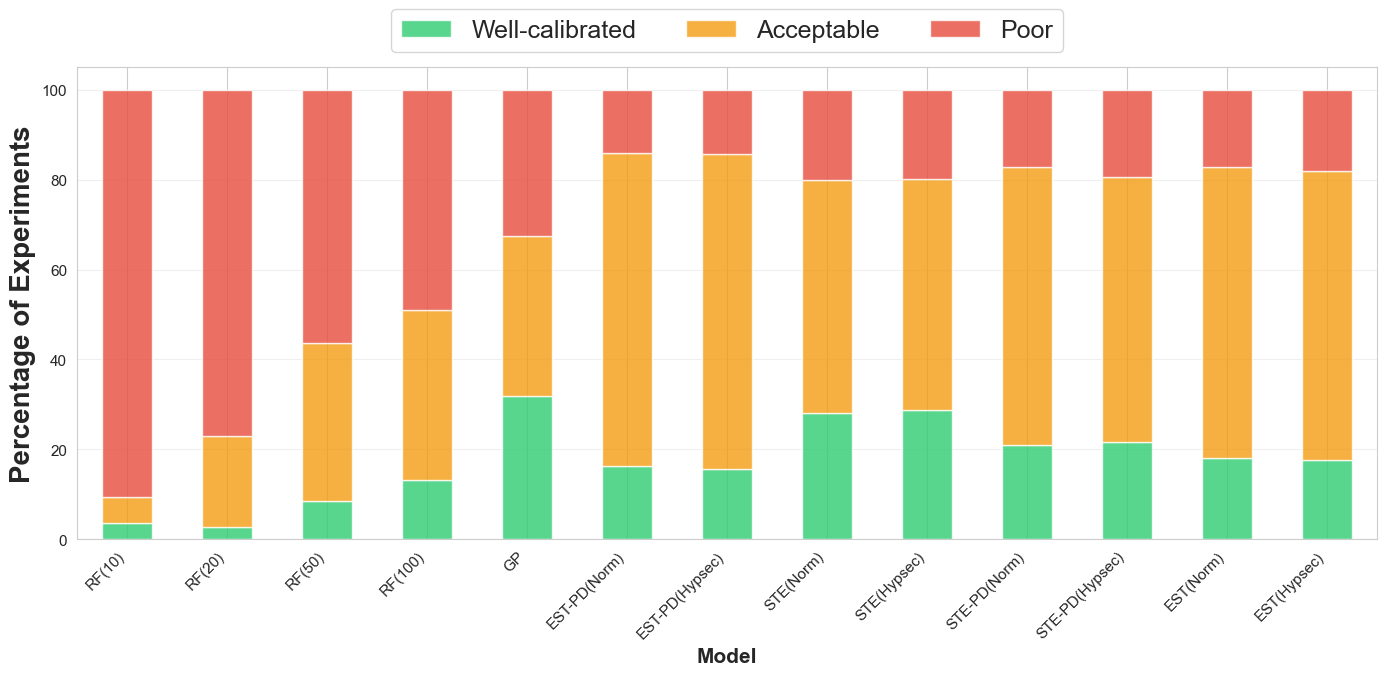

In [43]:
# Define calibration quality categories
def calibration_quality(coverage):
    abs_dev = abs(coverage - 0.95)
    if abs_dev < 0.02:
        return 'Well-calibrated'
    elif abs_dev < 0.05:
        return 'Acceptable'
    else:
        return 'Poor'

# Calculate calibration quality for each model
quality_counts = {}
for model in model_cols:
    qualities = ci_all_combined[model].apply(calibration_quality)
    quality_counts[model] = qualities.value_counts(normalize=True) * 100

quality_df = pd.DataFrame(quality_counts).T.fillna(0)
print("\n=== Calibration Quality Distribution (% of experiments) ===")
print(quality_df.round(1))

# Stacked bar plot
# order the columns
quality_df = quality_df[['Well-calibrated', 'Acceptable', 'Poor']]
fig, ax = plt.subplots(figsize=(14, 7))
quality_df.plot(kind='bar', stacked=True, ax=ax, 
                color=['#2ecc71', '#f39c12', '#e74c3c'],
                alpha=0.8)
ax.set_xlabel('Model', fontsize=15, fontweight='bold')
ax.set_ylabel('Percentage of Experiments', fontsize=20, fontweight='bold')
#ax.set_title('Calibration Quality Distribution Across Models', fontsize=14, fontweight='bold')
ax.set_xticklabels(quality_df.index, rotation=45, ha='right')
#ax.legend(title='Calibration Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper center', fontsize=18, ncol=3,
                  bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()
plt.savefig('ci_performance_dist.pdf', bbox_inches='tight',dpi=300, format='pdf')
plt.show()

In [44]:
def add_data_info(data_names):
    data_info = pd.DataFrame()
    p_list = []
    n_list = []
    for data_name in data_names:
        data = pd.read_csv(f'../../data/{data_name}.csv')
        p_list.append(data.shape[1]-1)
        n_list.append(data.shape[0])
    data_info['data'] = data_names
    data_info['P'] = p_list
    data_info['N'] = n_list
    return data_info

data_names = [
    'fertility', 
    'forest',
    'qsar_aquatic_toxicity',  
    'stock', 
    'yacht_hydrodynamics',
    'real_estate',
    'winequality-red',
    'winequality-white',
    'qsar_fish_toxicity',
    'Combined_Cycle_Power_Plant'
]

data_info_df = add_data_info(data_names)
data_name_mapping = {
    'Combined_Cycle_Power_Plant': 'CCPP',
    'qsar_fish_toxicity': 'Qsar Fish Toxicity',
    'real_estate': 'Real Estate',
    'yacht_hydrodynamics': 'Yacht Hydrodynamics',
    'qsar_aquatic_toxicity': 'Qsar Aquatic Toxicity',
    'fertility': 'Fertility',
    'stock': 'Stock',
    'winequality-red': 'Winequality (Red)',
    'winequality-white': 'Winequality (White)',
    'forest': 'Forest'
    }
data_info_df['data'] = data_info_df['data'].replace(data_name_mapping)
dataset_info = {
    data:{'n':data_info_df[data_info_df['data'] == data].N.item(),'p':data_info_df[data_info_df['data'] == data].P.item()} for data in data_info_df['data']
}

In [45]:
def plot_ci_coverage_grid(result_df, 
                          dataset_info,
                          save_path=None,
                          ncol=5,
                          plot_type='line',
                          figure_size=(20, 13),
                          show_legend=True):
    """
    Plot 95% CI coverage curves in a grid layout for multiple datasets
    """
    
    data_list = result_df['Data'].unique().tolist()
    rows = len(data_list) // ncol
    if len(data_list) % ncol != 0:
        rows += 1
    
    # Models to plot
    models = ['RF(10)', 'RF(20)', 'RF(50)', 'RF(100)', 'GP',
       'EST-PD(Norm)', 'EST-PD(Hypsec)','STE(Norm)','STE(Hypsec)']
    
    # Color mapping
    cmap = plt.get_cmap("tab10")
    color_mapping = {
        'RF(100)': cmap(0), 
        'EST-PD(Norm)': cmap(1),
        'EST-PD(Hypsec)': cmap(2),
        'RF(10)': cmap(3),
        'RF(20)': cmap(4),
        'RF(50)': cmap(5),
        'GP': cmap(6),
        'STE(Norm)': cmap(7),
        'STE(Hypsec)': cmap(8)
    }
    
    fig, axes = plt.subplots(rows, ncol, figsize=figure_size, sharex=False, sharey='row')
    
    # Handle case where there's only one row
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, data in enumerate(data_list):
        data_name = data
        data_df = result_df[result_df['Data'] == data]
        
        if len(data_df) == 0:
            continue
        
        # Get training sizes
        n_list = sorted(data_df['n_obs'].unique().tolist())
        n_list_strings = list(map(str, n_list))
        
        # Handle special cases for x-axis labels
        if len(n_list) > 4 and n_list[1] == 20:
            n_list_strings[1] = ''
        
        # Get dataset info
        n_obs = dataset_info.get(data, {}).get('n', 'N/A')
        dim = dataset_info.get(data, {}).get('p', 'N/A')
        
        for model in models:
            # Calculate mean and std for each training size
            grouped = data_df.groupby('n_obs')[model]
            mean_list = grouped.mean().values.tolist()
            std_list = grouped.std().values.tolist()
            
            # Calculate 95% confidence interval
            n_reps = data_df.groupby('n_obs').size().iloc[0]
            std_err = [1.96 * std / np.sqrt(n_reps) for std in std_list]
            
            model_label = model
            
            if plot_type == 'line':
                axes[i // ncol, i % ncol].plot(
                    n_list, mean_list, 
                    label=model_label, 
                    marker='o', 
                    color=color_mapping[model],
                    linewidth=2,
                    markersize=6
                )
            elif plot_type == 'errorbar':
                eb = axes[i // ncol, i % ncol].errorbar(
                    n_list, mean_list, yerr=std_err,
                    label=model_label,
                    color=color_mapping[model],
                    linewidth=3,
                    capsize=5,
                    marker='o',
                    markersize=6,
                    linestyle = '--' if model not in ['EST-PD(Norm)','EST-PD(Hypsec)','STE(Norm)','STE(Hypsec)'] else '-'
                )
                eb[-1][0].set_linestyle((0, (1, 1)))
        
        # Set title
        title_text = f"{data_name}\n($\mathit{{n={n_obs}}}$, $\mathit{{p={dim}}}$)"
        axes[i // ncol, i % ncol].set_title(title_text, fontsize=26)
        
        # Set tick parameters
        axes[i // ncol, i % ncol].tick_params(axis='x', labelsize=22)
        axes[i // ncol, i % ncol].tick_params(axis='y', labelsize=22)
        
        # Set x-axis ticks
        axes[i // ncol, i % ncol].set_xticks(n_list)
        axes[i // ncol, i % ncol].set_xticklabels(n_list_strings)
        axes[i // ncol, i % ncol].xaxis.set_tick_params(rotation=60)
        
        # Add grid
        axes[i // ncol, i % ncol].grid(alpha=0.3)
        
        # Add horizontal line at 0.95 (target coverage)
        axes[i // ncol, i % ncol].axhline(0.95, color='red', linestyle='--', linewidth=2)
        
        # Set y-axis limits
        axes[i // ncol, i % ncol].set_ylim([0.7, 1.05])

        # set y max to 1.0
        axes[i // ncol, i % ncol].set_yticks(np.arange(0.7, 1.05, 0.1))
        axes[i // ncol, i % ncol].set_ylim(0.7, 1.0)
    
    # Hide unused subplots
    for i in range(len(data_list), rows * ncol):
        axes[i // ncol, i % ncol].axis('off')
    
    # Add legend
    if show_legend:
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', fontsize=22, ncol=7,
                  bbox_to_anchor=(0.5, 1.10))
    
    # Add common axis labels
    fig.text(-0.01, 0.5, '95% Confidence Interval', 
             va='center', rotation='vertical', fontsize=30)
    fig.text(0.5, -0.02, 'Training Size', 
             ha='center', fontsize=28)
    
    plt.subplots_adjust(wspace=0.05, hspace=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight',dpi=300, format='pdf')
    return fig

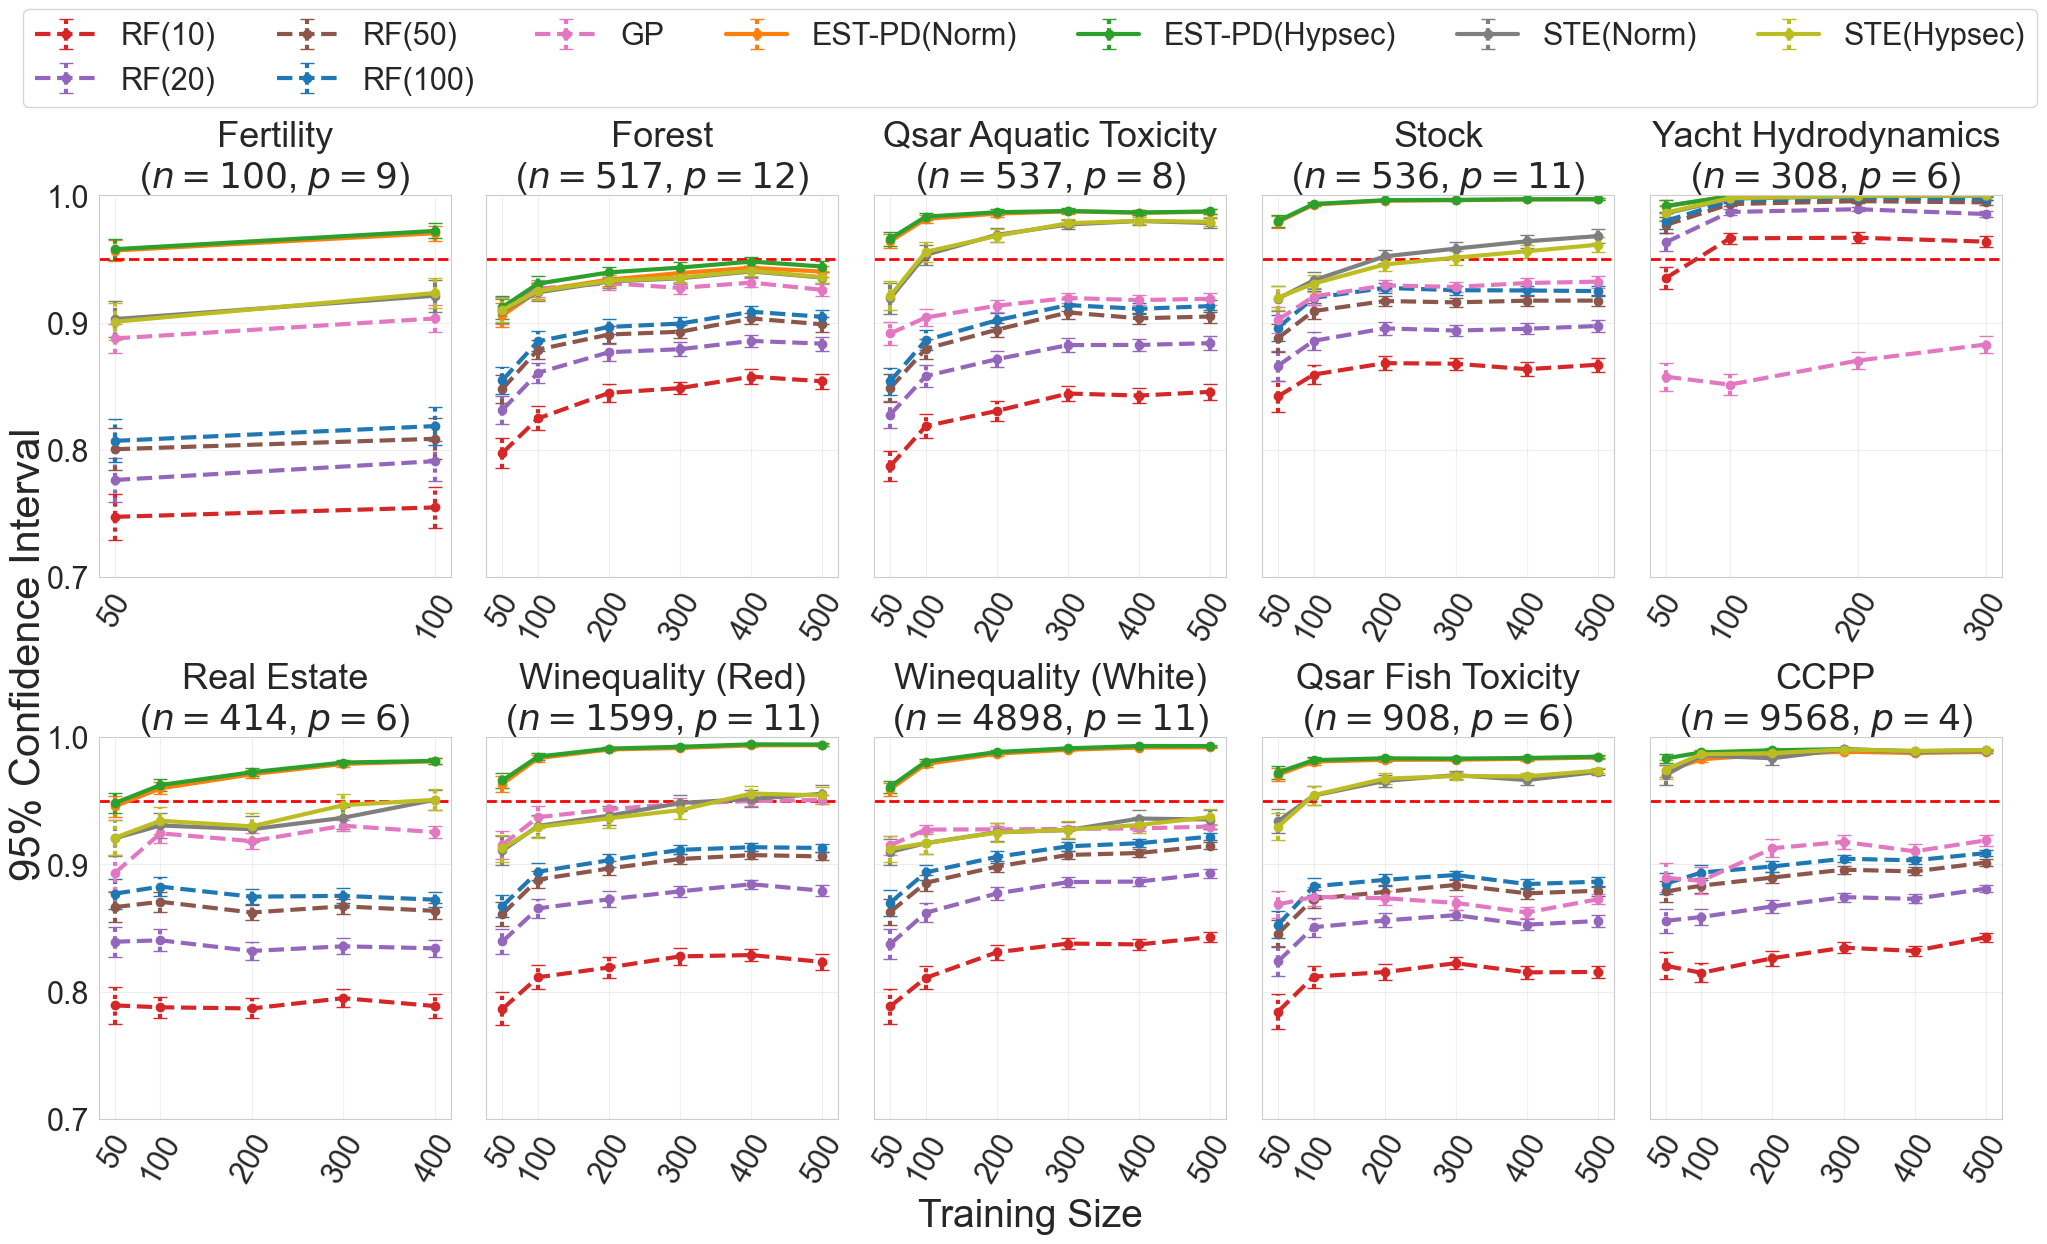

In [46]:
# Create with error bars
fig = plot_ci_coverage_grid(
    ci_all_combined,
    dataset_info,
    save_path = 'ci_datasets.pdf',
    ncol=5,
    plot_type='errorbar',
    figure_size=(20, 11),
    show_legend=True
)

plt.show()

In [47]:
CICR_mean = ci_all_combined.groupby(['Data','p']).mean().drop(columns=['r','n_obs']).reset_index()
CICR_std = ci_all_combined.groupby(['Data','p']).std().drop(columns=['r','n_obs']).reset_index()
ci_all_combined['cases'] = 1
cased_by_n_obs = ci_all_combined.groupby(['Data']).sum().reset_index()
CICR_std['cases'] = cased_by_n_obs['cases']

In [48]:
CICR_mean_95CI = pd.DataFrame()
CICR_mean_95CI['Data'] = CICR_mean['Data']
CICR_mean_95CI['p'] = CICR_mean['p']

for col in CICR_mean.columns[2:]:
    CICR_mean_95CI[col] = [f"{m:.2f} ({s:.4f})" for m, s in zip(CICR_mean[col], CICR_std[col]/np.sqrt(CICR_std['cases']))]

In [49]:
CICR_mean_95CI

,Data,p,RF(10),RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec),STE-PD(Norm),STE-PD(Hypsec),EST(Norm),EST(Hypsec)
0,CCPP,4,0.83 (0.0014),0.87 (0.0012),0.89 (0.0011),0.90 (0.0011),0.91 (0.0017),0.98 (0.0005),0.99 (0.0004),0.98 (0.0009),0.99 (0.0008),0.98 (0.0007),0.99 (0.0005),0.98 (0.0007),0.99 (0.0005)
1,Fertility,9,0.75 (0.0062),0.78 (0.0060),0.80 (0.0059),0.81 (0.0057),0.90 (0.0040),0.96 (0.0026),0.96 (0.0026),0.91 (0.0049),0.91 (0.0048),0.95 (0.0031),0.95 (0.0032),0.96 (0.0030),0.96 (0.0030)
2,Forest,12,0.84 (0.0018),0.87 (0.0017),0.89 (0.0016),0.89 (0.0016),0.93 (0.0014),0.93 (0.0013),0.94 (0.0013),0.93 (0.0013),0.93 (0.0013),0.93 (0.0013),0.93 (0.0013),0.93 (0.0013),0.93 (0.0013)
3,Qsar Aquatic Toxicity,8,0.83 (0.0019),0.87 (0.0017),0.89 (0.0017),0.90 (0.0016),0.91 (0.0013),0.98 (0.0007),0.98 (0.0007),0.96 (0.0017),0.96 (0.0016),0.99 (0.0007),0.99 (0.0006),0.99 (0.0008),0.99 (0.0006)
4,Qsar Fish Toxicity,6,0.81 (0.0017),0.85 (0.0015),0.87 (0.0014),0.88 (0.0014),0.87 (0.0014),0.98 (0.0006),0.98 (0.0006),0.96 (0.0013),0.96 (0.0014),0.99 (0.0005),0.99 (0.0005),0.99 (0.0004),0.99 (0.0004)
5,Real Estate,6,0.79 (0.0022),0.84 (0.0019),0.87 (0.0018),0.88 (0.0018),0.92 (0.0020),0.97 (0.0012),0.97 (0.0012),0.93 (0.0024),0.94 (0.0024),0.98 (0.0010),0.98 (0.0009),0.98 (0.0010),0.98 (0.0009)
6,Stock,11,0.86 (0.0015),0.89 (0.0015),0.91 (0.0013),0.92 (0.0013),0.92 (0.0013),0.99 (0.0005),0.99 (0.0005),0.95 (0.0015),0.94 (0.0015),0.95 (0.0015),0.94 (0.0015),0.97 (0.0015),0.97 (0.0016)
7,Winequality (Red),11,0.82 (0.0018),0.87 (0.0014),0.89 (0.0013),0.90 (0.0013),0.94 (0.0015),0.99 (0.0008),0.99 (0.0007),0.94 (0.0018),0.94 (0.0018),0.98 (0.0011),0.98 (0.0012),0.98 (0.0010),0.98 (0.0010)
8,Winequality (White),11,0.82 (0.0018),0.87 (0.0016),0.90 (0.0014),0.90 (0.0014),0.93 (0.0008),0.98 (0.0007),0.98 (0.0007),0.93 (0.0017),0.92 (0.0016),0.96 (0.0010),0.96 (0.0010),0.97 (0.0010),0.97 (0.0010)
9,Yacht Hydrodynamics,6,0.96 (0.0016),0.98 (0.0012),0.99 (0.0010),0.99 (0.0009),0.87 (0.0022),1.00 (0.0007),1.00 (0.0007),1.00 (0.0008),1.00 (0.0008),1.00 (0.0007),1.00 (0.0007),1.00 (0.0005),1.00 (0.0004)


In [50]:
est_pd_results = CICR_mean_95CI[['Data',
                                'p',
                                'RF(10)',
                                'RF(20)',
                                'RF(50)',
                                'RF(100)',
                                'GP',
                                'EST-PD(Norm)',
                                'EST-PD(Hypsec)',
                                'STE(Norm)',
                                'STE(Hypsec)']]
est_pd_results.to_csv('CICR_mean_95CI_EST-PD_STE.csv', index=False)

In [51]:
est_pd_results

,Data,p,RF(10),RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec)
0,CCPP,4,0.83 (0.0014),0.87 (0.0012),0.89 (0.0011),0.90 (0.0011),0.91 (0.0017),0.98 (0.0005),0.99 (0.0004),0.98 (0.0009),0.99 (0.0008)
1,Fertility,9,0.75 (0.0062),0.78 (0.0060),0.80 (0.0059),0.81 (0.0057),0.90 (0.0040),0.96 (0.0026),0.96 (0.0026),0.91 (0.0049),0.91 (0.0048)
2,Forest,12,0.84 (0.0018),0.87 (0.0017),0.89 (0.0016),0.89 (0.0016),0.93 (0.0014),0.93 (0.0013),0.94 (0.0013),0.93 (0.0013),0.93 (0.0013)
3,Qsar Aquatic Toxicity,8,0.83 (0.0019),0.87 (0.0017),0.89 (0.0017),0.90 (0.0016),0.91 (0.0013),0.98 (0.0007),0.98 (0.0007),0.96 (0.0017),0.96 (0.0016)
4,Qsar Fish Toxicity,6,0.81 (0.0017),0.85 (0.0015),0.87 (0.0014),0.88 (0.0014),0.87 (0.0014),0.98 (0.0006),0.98 (0.0006),0.96 (0.0013),0.96 (0.0014)
5,Real Estate,6,0.79 (0.0022),0.84 (0.0019),0.87 (0.0018),0.88 (0.0018),0.92 (0.0020),0.97 (0.0012),0.97 (0.0012),0.93 (0.0024),0.94 (0.0024)
6,Stock,11,0.86 (0.0015),0.89 (0.0015),0.91 (0.0013),0.92 (0.0013),0.92 (0.0013),0.99 (0.0005),0.99 (0.0005),0.95 (0.0015),0.94 (0.0015)
7,Winequality (Red),11,0.82 (0.0018),0.87 (0.0014),0.89 (0.0013),0.90 (0.0013),0.94 (0.0015),0.99 (0.0008),0.99 (0.0007),0.94 (0.0018),0.94 (0.0018)
8,Winequality (White),11,0.82 (0.0018),0.87 (0.0016),0.90 (0.0014),0.90 (0.0014),0.93 (0.0008),0.98 (0.0007),0.98 (0.0007),0.93 (0.0017),0.92 (0.0016)
9,Yacht Hydrodynamics,6,0.96 (0.0016),0.98 (0.0012),0.99 (0.0010),0.99 (0.0009),0.87 (0.0022),1.00 (0.0007),1.00 (0.0007),1.00 (0.0008),1.00 (0.0008)
